# NHANES Pulse Consumption — Nativity × Race/Ethnicity Analysis

Pulse consumption stratified by US-born vs foreign-born within each race/ethnicity group,
using NHANES 1999–2018.

## Race/ethnicity variables across NHANES cycles

| Variable | Categories | Cycles |
|---|---|---|
| RIDRETH1 | 1=Mexican American, 2=Other Hispanic, 3=NH White, 4=NH Black, 5=Other | All 10 (1999–2018) |
| RIDRETH3 | 1=Mex Am, 2=Other Hisp, 3=NHW, 4=NHB, **6=NH Asian**, **7=Other/Multi** | 2011–2018 (4 cycles) |

For the **Hispanic**, **NH White**, and **NH Black** groups, all 10 cycles are available via RIDRETH1.
For **NH Asian** and **Other/Multi-Racial**, only 2011–2018 (RIDRETH3) is available.

Nativity is coded from DMDBORN/DMDBORN2/DMDBORN4 as US-born vs foreign-born.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

DATA_DIR = os.path.abspath(os.path.join('..', 'data'))
DERIVED = os.path.join(DATA_DIR, 'derived')

df = pd.read_parquet(os.path.join(DERIVED, 'pulse_consumption.parquet'))

n_cycles = df['CYCLE'].nunique()
df['WT_POOLED'] = df['WTDRD1'] / n_cycles
has_wt = df['WT_POOLED'].notna() & (df['WT_POOLED'] > 0)
dfw = df[has_wt].copy()

# Create unified nativity flag: US-born vs Foreign-born
# (Mexico-born is a subtype of foreign-born)
dfw['FOREIGN_BORN'] = dfw['NATIVITY'].isin(['Foreign-born', 'Mexico-born']).astype(int)
dfw['NATIVITY_2'] = dfw['NATIVITY'].map(
    {'US-born': 'US-born', 'Foreign-born': 'Foreign-born', 'Mexico-born': 'Foreign-born'})

# Create race/ethnicity groups using RIDRETH1 for all 10 cycles
# and RIDRETH3 where available for Asian & Other/Multi
dfw['RACE_4'] = dfw['RIDRETH1'].map({
    1: 'Hispanic', 2: 'Hispanic', 3: 'NH White', 4: 'NH Black', 5: 'Other'})

# For 2011+ cycles, reclassify using RIDRETH3
has_r3 = dfw['RIDRETH3'].notna()
dfw.loc[has_r3 & (dfw['RIDRETH3'] == 6), 'RACE_4'] = 'NH Asian'
dfw.loc[has_r3 & (dfw['RIDRETH3'] == 7), 'RACE_4'] = 'Other/Multi-Racial'

print(f'Loaded {len(dfw):,} participants')
print(f'\nRace/ethnicity (RACE_4):')
print(dfw['RACE_4'].value_counts())
print(f'\nNativity:')
print(dfw['NATIVITY_2'].value_counts(dropna=False))

Loaded 48,736 participants

Race/ethnicity (RACE_4):
RACE_4
NH White              21865
Hispanic              12515
NH Black              10193
NH Asian               2282
Other                  1165
Other/Multi-Racial      716
Name: count, dtype: int64

Nativity:
NATIVITY_2
US-born         36036
Foreign-born    12680
NaN                20
Name: count, dtype: int64


In [2]:
def weighted_mean(values, weights):
    mask = values.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    return np.average(values[mask], weights=weights[mask])

def weighted_pct(binary, weights):
    return 100 * weighted_mean(binary, weights)

def weighted_ci(values, weights, alpha=0.05):
    mask = values.notna() & weights.notna() & (weights > 0)
    v = values[mask].values
    w = weights[mask].values
    wm = np.average(v, weights=w)
    n_eff = (w.sum())**2 / (w**2).sum()
    wvar = np.average((v - wm)**2, weights=w)
    se = np.sqrt(wvar / n_eff)
    z = stats.norm.ppf(1 - alpha / 2)
    return wm - z * se, wm + z * se

def group_stats(data, consumer_col, oz_col, wt_col):
    """Compute prevalence and consumption for a subgroup."""
    if len(data) == 0:
        return dict(N=0, n_consumers=0, prev_pct=np.nan,
                    prev_ci_lo=np.nan, prev_ci_hi=np.nan,
                    oz_all=np.nan, oz_consumers=np.nan)
    cons = data[data[consumer_col] == 1]
    prev = weighted_pct(data[consumer_col], data[wt_col])
    lo, hi = weighted_ci(data[consumer_col], data[wt_col])
    oz_all = weighted_mean(data[oz_col], data[wt_col])
    oz_cons = weighted_mean(cons[oz_col], cons[wt_col]) if len(cons) > 0 else np.nan
    return dict(
        N=len(data), n_consumers=int(data[consumer_col].sum()),
        prev_pct=prev, prev_ci_lo=100*lo, prev_ci_hi=100*hi,
        oz_all=oz_all, oz_consumers=oz_cons,
    )

## Nativity × race/ethnicity cross-tabulation

Pulse consumer prevalence and mean consumption by US-born vs foreign-born
within each race/ethnicity group.

In [3]:
# Cross-tabulation: race × nativity
RACE_GROUPS = ['Hispanic', 'NH Asian', 'NH White', 'NH Black', 'Other/Multi-Racial']
NATIVITY_GROUPS = ['US-born', 'Foreign-born']

rows = []
for race in RACE_GROUPS:
    for nativity in NATIVITY_GROUPS:
        sub = dfw[(dfw['RACE_4'] == race) & (dfw['NATIVITY_2'] == nativity)]
        if len(sub) == 0:
            continue
        s = group_stats(sub, 'IS_CONSUMER', 'PULSE_OZ_EQ', 'WT_POOLED')
        cycles_present = sub['CYCLE'].nunique()
        rows.append({
            'Race/Ethnicity': race,
            'Nativity': nativity,
            'Cycles': cycles_present,
            'N': s['N'],
            'n consumers': s['n_consumers'],
            'Prevalence %': s['prev_pct'],
            '95% CI': f"({s['prev_ci_lo']:.1f}–{s['prev_ci_hi']:.1f})",
            'oz/day (all)': s['oz_all'],
            'oz/day (consumers)': s['oz_consumers'],
        })

cross_df = pd.DataFrame(rows)
display(cross_df.style.format({
    'N': '{:,}', 'n consumers': '{:,}', 'Cycles': '{:d}',
    'Prevalence %': '{:.1f}', 'oz/day (all)': '{:.2f}', 'oz/day (consumers)': '{:.2f}',
}).set_caption('Pulse consumption: US-born vs foreign-born by race/ethnicity (weighted)'))

,Race/Ethnicity,Nativity,Cycles,N,n consumers,Prevalence %,95% CI,oz/day (all),oz/day (consumers)
0,Hispanic,US-born,10,"4,623","1,272",25.0,(23.1–26.8),0.70,2.79
1,Hispanic,Foreign-born,10,"7,879","3,117",38.4,(36.9–39.9),1.27,3.31
2,NH Asian,US-born,4,316,61,20.1,(14.5–25.6),0.27,1.36
3,NH Asian,Foreign-born,4,"1,965",587,29.3,(26.8–31.7),0.73,2.49
4,NH White,US-born,10,"20,800","3,213",16.7,(16.0–17.4),0.36,2.17
5,NH White,Foreign-born,10,"1,060",165,18.1,(15.0–21.2),0.42,2.30
6,NH Black,US-born,10,"9,200","1,178",13.2,(12.4–14.1),0.34,2.56
7,NH Black,Foreign-born,10,992,211,20.7,(17.6–23.9),0.56,2.70
8,Other/Multi-Racial,US-born,4,604,102,17.4,(13.0–21.8),0.48,2.76
9,Other/Multi-Racial,Foreign-born,4,112,30,24.0,(11.0–37.0),0.57,2.39


## Visualization: Foreign-born vs US-born prevalence gap

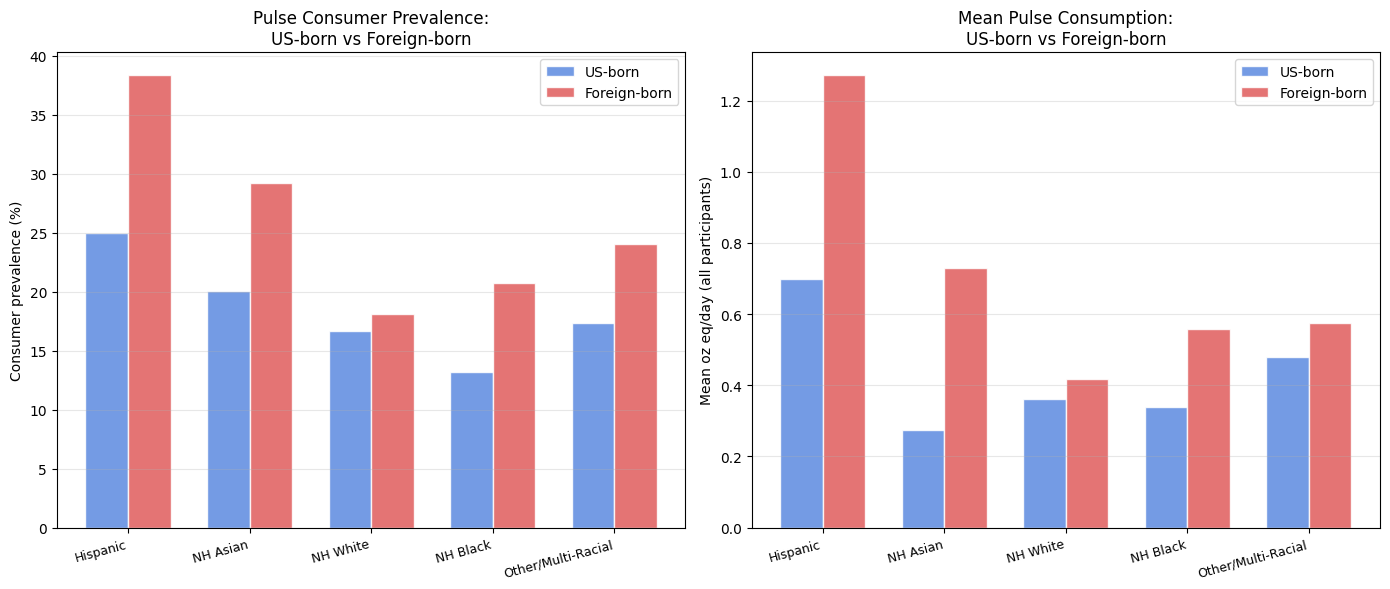

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Reshape for grouped bar chart
pivot_prev = cross_df.pivot(index='Race/Ethnicity', columns='Nativity', values='Prevalence %')
pivot_oz = cross_df.pivot(index='Race/Ethnicity', columns='Nativity', values='oz/day (all)')

# Reorder races
race_order = [r for r in RACE_GROUPS if r in pivot_prev.index]
pivot_prev = pivot_prev.loc[race_order]
pivot_oz = pivot_oz.loc[race_order]

x = np.arange(len(race_order))
width = 0.35
colors = {'US-born': '#5c8ae0', 'Foreign-born': '#e05c5c'}

# Prevalence
for i, nat in enumerate(NATIVITY_GROUPS):
    if nat in pivot_prev.columns:
        vals = pivot_prev[nat].fillna(0).values
        ax1.bar(x + i * width - width/2, vals, width, label=nat,
                color=colors[nat], alpha=0.85, edgecolor='white')

ax1.set_xticks(x)
ax1.set_xticklabels(race_order, fontsize=9, rotation=15, ha='right')
ax1.set_ylabel('Consumer prevalence (%)')
ax1.set_title('Pulse Consumer Prevalence:\nUS-born vs Foreign-born')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Mean oz/day
for i, nat in enumerate(NATIVITY_GROUPS):
    if nat in pivot_oz.columns:
        vals = pivot_oz[nat].fillna(0).values
        ax2.bar(x + i * width - width/2, vals, width, label=nat,
                color=colors[nat], alpha=0.85, edgecolor='white')

ax2.set_xticks(x)
ax2.set_xticklabels(race_order, fontsize=9, rotation=15, ha='right')
ax2.set_ylabel('Mean oz eq/day (all participants)')
ax2.set_title('Mean Pulse Consumption:\nUS-born vs Foreign-born')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Pulse type breakdown by race/ethnicity × nativity

Which pulse types drive the nativity gap within each group?

In [5]:
pt_rows = []
for race in RACE_GROUPS:
    for nativity in NATIVITY_GROUPS:
        sub = dfw[(dfw['RACE_4'] == race) & (dfw['NATIVITY_2'] == nativity)]
        if len(sub) < 30:
            continue
        row = {'Race/Ethnicity': race, 'Nativity': nativity, 'N': len(sub)}
        for pt in ['BEANS', 'CHICKPEAS', 'LENTILS', 'PEAS']:
            col = f'PULSE_CUPS_{pt}'
            row[pt.lower()] = weighted_mean(sub[col] * 4, sub['WT_POOLED'])
        row['total'] = weighted_mean(sub['PULSE_OZ_EQ'], sub['WT_POOLED'])
        pt_rows.append(row)

pt_cross_df = pd.DataFrame(pt_rows)
display(pt_cross_df.style.format({
    'N': '{:,}',
    'beans': '{:.3f}', 'chickpeas': '{:.3f}', 'lentils': '{:.3f}', 'peas': '{:.3f}',
    'total': '{:.3f}',
}).set_caption('Mean oz eq/day by pulse type, race/ethnicity × nativity (weighted)'))

,Race/Ethnicity,Nativity,N,beans,chickpeas,lentils,peas,total
0,Hispanic,US-born,"4,623",0.651,0.009,0.036,0.001,0.697
1,Hispanic,Foreign-born,"7,879",1.201,0.016,0.052,0.003,1.273
2,NH Asian,US-born,316,0.129,0.034,0.105,0.005,0.273
3,NH Asian,Foreign-born,"1,965",0.391,0.052,0.267,0.019,0.728
4,NH White,US-born,"20,800",0.322,0.023,0.013,0.005,0.363
5,NH White,Foreign-born,"1,060",0.335,0.019,0.054,0.009,0.417
6,NH Black,US-born,"9,200",0.314,0.001,0.002,0.021,0.339
7,NH Black,Foreign-born,992,0.491,0.009,0.036,0.023,0.559
8,Other/Multi-Racial,US-born,604,0.443,0.029,0.003,0.006,0.480
9,Other/Multi-Racial,Foreign-born,112,0.502,0.043,0.030,0.000,0.574


## Temporal trends: Foreign-born vs US-born Hispanic

Hispanic group has the largest nativity gap and all 10 cycles.
Also show NH Asian (2011+), NH White, and NH Black.

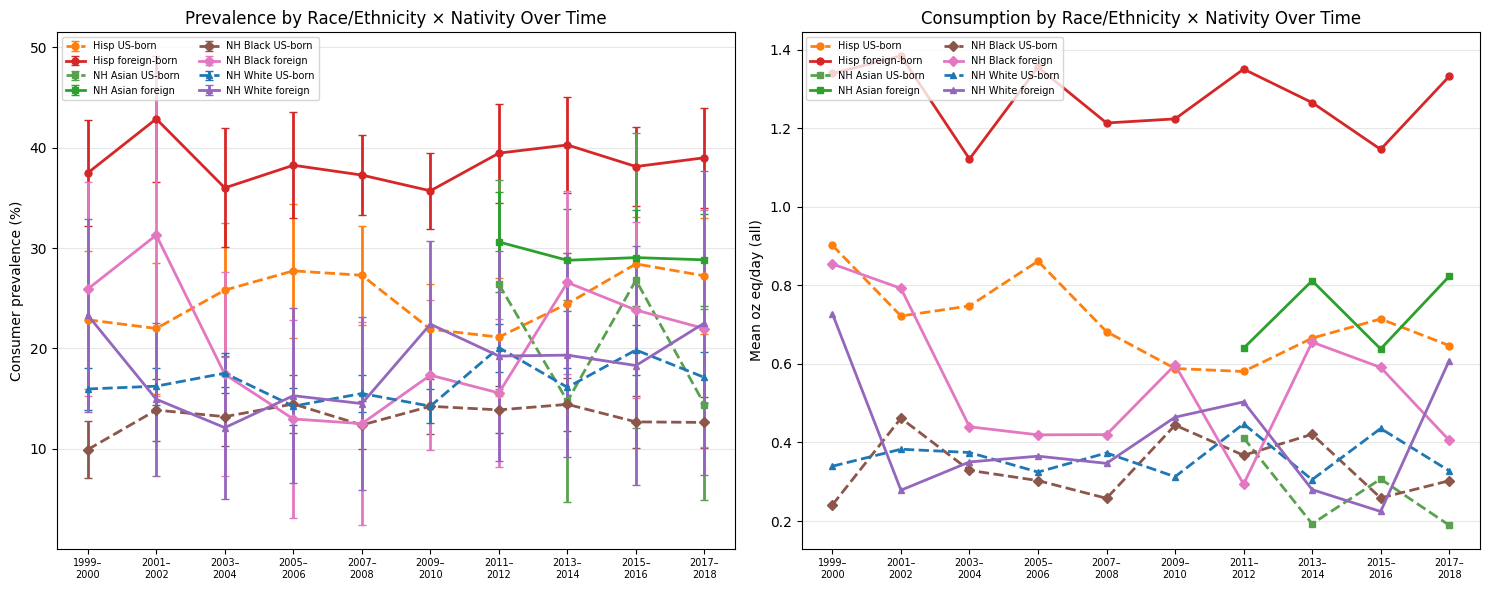

In [6]:
TREND_CONFIGS = [
    ('Hispanic', 'Foreign-born', 'Hisp foreign-born', '#d62728', 'o'),
    ('Hispanic', 'US-born',      'Hisp US-born',      '#ff7f0e', 'o'),
    ('NH Asian', 'Foreign-born', 'NH Asian foreign',   '#2ca02c', 's'),
    ('NH Asian', 'US-born',      'NH Asian US-born',   '#59a14f', 's'),
    ('NH White', 'Foreign-born', 'NH White foreign',   '#9467bd', '^'),
    ('NH White', 'US-born',      'NH White US-born',   '#1f77b4', '^'),
    ('NH Black', 'Foreign-born', 'NH Black foreign',   '#e377c2', 'D'),
    ('NH Black', 'US-born',      'NH Black US-born',   '#8c564b', 'D'),
]

cycles_sorted = sorted(dfw['CYCLE'].unique())

trend_rows = []
for cycle in cycles_sorted:
    sub_cycle = dfw[dfw['CYCLE'] == cycle]
    for race, nativity, label, color, marker in TREND_CONFIGS:
        sub = sub_cycle[(sub_cycle['RACE_4'] == race) & (sub_cycle['NATIVITY_2'] == nativity)]
        if len(sub) < 30:
            continue
        s = group_stats(sub, 'IS_CONSUMER', 'PULSE_OZ_EQ', 'WTDRD1')
        trend_rows.append({
            'Cycle': cycle, 'Group': label,
            'Prev %': s['prev_pct'], 'CI lo': s['prev_ci_lo'], 'CI hi': s['prev_ci_hi'],
            'oz all': s['oz_all'],
        })

trend_df = pd.DataFrame(trend_rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
x_map = {c: i for i, c in enumerate(cycles_sorted)}
xlabels = [c.replace('-', '–\n') for c in cycles_sorted]

config_lookup = {label: (color, marker) for _, _, label, color, marker in TREND_CONFIGS}

for grp_label, gdf in trend_df.groupby('Group'):
    x = [x_map[c] for c in gdf['Cycle']]
    color, marker = config_lookup[grp_label]
    ls = '--' if 'US-born' in grp_label else '-'
    ax1.errorbar(x, gdf['Prev %'],
                 yerr=[gdf['Prev %'] - gdf['CI lo'], gdf['CI hi'] - gdf['Prev %']],
                 marker=marker, capsize=3, linewidth=2, linestyle=ls,
                 color=color, label=grp_label, markersize=5)
    ax2.plot(x, gdf['oz all'], marker=marker, linewidth=2, linestyle=ls,
             color=color, label=grp_label, markersize=5)

for ax in [ax1, ax2]:
    ax.set_xticks(range(len(cycles_sorted)))
    ax.set_xticklabels(xlabels, fontsize=7)
    ax.legend(fontsize=7, ncol=2, loc='upper left')
    ax.grid(axis='y', alpha=0.3)

ax1.set_ylabel('Consumer prevalence (%)')
ax1.set_title('Prevalence by Race/Ethnicity × Nativity Over Time')
ax2.set_ylabel('Mean oz eq/day (all)')
ax2.set_title('Consumption by Race/Ethnicity × Nativity Over Time')

plt.tight_layout()
plt.show()

## Education stratification within nativity × race/ethnicity

The Drewnowski paper found higher consumption among groups with lower education.
Does this hold within nativity subgroups?

In [7]:
edu_rows = []
for race in RACE_GROUPS:
    for nativity in NATIVITY_GROUPS:
        for edu in ['High school or less', 'Some college or more']:
            sub = dfw[(dfw['RACE_4'] == race) & (dfw['NATIVITY_2'] == nativity)
                      & (dfw['EDUCATION'] == edu)]
            if len(sub) < 30:
                continue
            s = group_stats(sub, 'IS_CONSUMER', 'PULSE_OZ_EQ', 'WT_POOLED')
            edu_rows.append({
                'Race/Ethnicity': race, 'Nativity': nativity,
                'Education': edu, 'N': s['N'],
                'Prevalence %': s['prev_pct'],
                'oz/day (all)': s['oz_all'],
                'oz/day (consumers)': s['oz_consumers'],
            })

edu_cross_df = pd.DataFrame(edu_rows)
display(edu_cross_df.style.format({
    'N': '{:,}', 'Prevalence %': '{:.1f}',
    'oz/day (all)': '{:.2f}', 'oz/day (consumers)': '{:.2f}',
}).set_caption('Pulse consumption by education × nativity × race/ethnicity (weighted)'))

,Race/Ethnicity,Nativity,Education,N,Prevalence %,oz/day (all),oz/day (consumers)
0,Hispanic,US-born,High school or less,"2,556",24.9,0.76,3.05
1,Hispanic,US-born,Some college or more,"2,059",24.9,0.63,2.51
2,Hispanic,Foreign-born,High school or less,"6,118",40.6,1.37,3.37
3,Hispanic,Foreign-born,Some college or more,"1,750",32.4,1.02,3.14
4,NH Asian,US-born,High school or less,42,8.4,0.02,0.29
5,NH Asian,US-born,Some college or more,274,23.0,0.33,1.46
6,NH Asian,Foreign-born,High school or less,529,23.1,0.45,1.93
7,NH Asian,Foreign-born,Some college or more,"1,436",31.5,0.83,2.63
8,NH White,US-born,High school or less,"8,819",14.5,0.35,2.41
9,NH White,US-born,Some college or more,"11,969",18.0,0.37,2.06
